# Customer Churn Analysis for Telecom Industry

**Dataset:** [IBM Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 customers, 21 attributes.

**Objective:** Predict churn and derive actionable strategies to retain users in a highly competitive telecom environment.

**Tools:** Python (Pandas, Scikit-learn, Matplotlib/Seaborn), SQL (SQLite)

Pipeline:
1. Data loading & cleaning
2. SQL aggregation (contract, tenure, charges, services)
3. Exploratory Data Analysis (EDA)
4. Binary classification model for churn
5. Model explainability (permutation / ELI5-style feature importance)
6. Customer segmentation: At Risk, Loyal, Dormant
7. Final recommendations


In [5]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, classification_report)
from sklearn.inspection import permutation_importance

sns.set_style("whitegrid")
%matplotlib inline

raw = pd.read_csv("../data/Telco-Customer-Churn.csv")
raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
raw.dtypes
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 1. Data Cleaning
`TotalCharges` is stored as text and has 11 blank values for brand-new customers (tenure = 0); these are imputed to 0.

In [7]:
df = raw.copy()
df["TotalCharges"] = df["TotalCharges"].replace(" ", pd.NA)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

df.columns = [
    "customer_id","gender","senior_citizen","partner","dependents",
    "tenure_months","phone_service","multiple_lines","internet_service",
    "online_security","online_backup","device_protection","tech_support",
    "streaming_tv","streaming_movies","contract","paperless_billing",
    "payment_method","monthly_charges","total_charges","churn",
]
df["churn_flag"] = (df["churn"] == "Yes").astype(int)
df["senior_citizen"] = df["senior_citizen"].map({0:"No", 1:"Yes"})

print(df.shape)
print("Churn rate: {:.2%}".format(df["churn_flag"].mean()))
df.head()

(7043, 22)
Churn rate: 26.54%


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,churn_flag
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 2. SQL Aggregation
Load into SQLite and aggregate churn by contract, tenure, charges, and services.

In [8]:
conn = sqlite3.connect(":memory:")
df.to_sql("customers", conn, index=False)

query = '''
SELECT contract, COUNT(*) AS total, SUM(churn_flag) AS churned,
       ROUND(100.0*SUM(churn_flag)/COUNT(*),1) AS churn_rate_pct
FROM customers GROUP BY contract ORDER BY churn_rate_pct DESC;
'''
pd.read_sql_query(query, conn)

,contract,total,churned,churn_rate_pct
0,Month-to-month,3875,1655,42.7
1,One year,1473,166,11.3
2,Two year,1695,48,2.8


In [9]:
query2 = '''
SELECT
    CASE
        WHEN tenure_months <= 12 THEN '0-12 months'
        WHEN tenure_months <= 24 THEN '13-24 months'
        WHEN tenure_months <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_bucket,
    COUNT(*) AS total_customers,
    ROUND(100.0*SUM(churn_flag)/COUNT(*),1) AS churn_rate_pct
FROM customers GROUP BY tenure_bucket ORDER BY churn_rate_pct DESC;
'''
pd.read_sql_query(query2, conn)

,tenure_bucket,total_customers,churn_rate_pct
0,0-12 months,2186,47.4
1,13-24 months,1024,28.7
2,25-48 months,1594,20.4
3,49+ months,2239,9.5


In [10]:
query3 = '''
SELECT payment_method, COUNT(*) AS total,
       ROUND(100.0*SUM(churn_flag)/COUNT(*),1) AS churn_rate_pct
FROM customers GROUP BY payment_method ORDER BY churn_rate_pct DESC;
'''
pd.read_sql_query(query3, conn)

,payment_method,total,churn_rate_pct
0,Electronic check,2365,45.3
1,Mailed check,1612,19.1
2,Bank transfer (automatic),1544,16.7
3,Credit card (automatic),1522,15.2


## 3. Exploratory Data Analysis

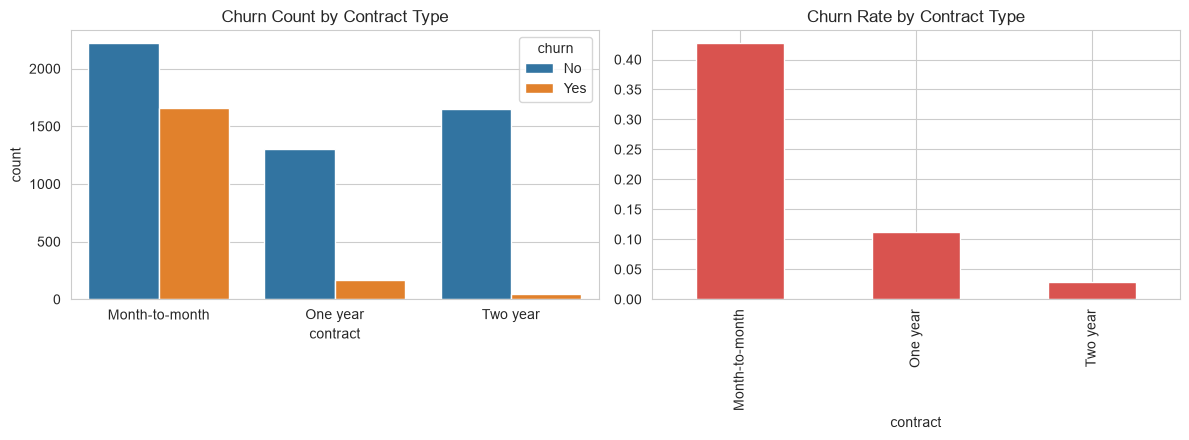

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df, x="contract", hue="churn", ax=axes[0])
axes[0].set_title("Churn Count by Contract Type")
churn_rate = df.groupby("contract")["churn_flag"].mean().sort_values(ascending=False)
churn_rate.plot(kind="bar", ax=axes[1], color="#d9534f")
axes[1].set_title("Churn Rate by Contract Type")
plt.tight_layout(); plt.show()

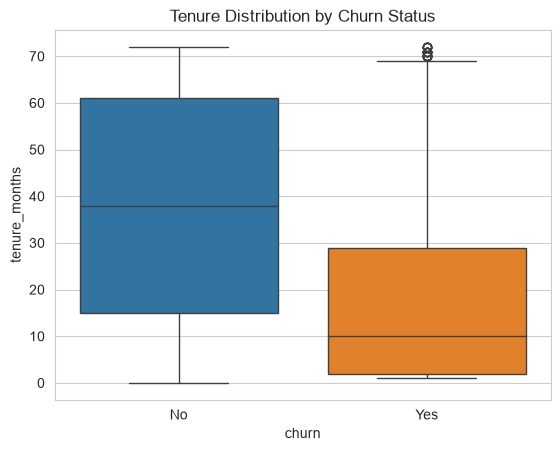

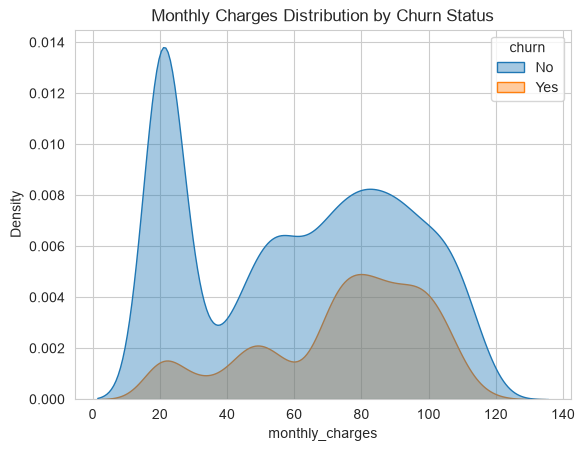

In [12]:
sns.boxplot(data=df, x="churn", y="tenure_months", hue="churn", legend=False)
plt.title("Tenure Distribution by Churn Status")
plt.show()

sns.kdeplot(data=df, x="monthly_charges", hue="churn", fill=True, alpha=0.4)
plt.title("Monthly Charges Distribution by Churn Status")
plt.show()

**Key observations:** Month-to-month contracts churn at 42.7% vs 2.8% for two-year contracts. Churned customers have far shorter average tenure (~18 months vs ~38) and pay higher monthly charges (~$74 vs ~$61) on average — consistent with fiber-optic/no-tech-support customers churning more.

## 4. Binary Classification Model

In [13]:
model_df = df.copy()
cat_cols = ["gender","senior_citizen","partner","dependents","phone_service",
            "multiple_lines","internet_service","online_security","online_backup",
            "device_protection","tech_support","streaming_tv","streaming_movies",
            "contract","paperless_billing","payment_method"]
for c in cat_cols:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])

feature_cols = [c for c in model_df.columns if c not in ["customer_id","churn","churn_flag"]]
X = model_df[feature_cols]
y = model_df["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                      random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=2000, class_weight="balanced")
log_reg.fit(X_train_s, y_train)
y_pred_lr = log_reg.predict(X_test_s)
y_proba_lr = log_reg.predict_proba(X_test_s)[:,1]

rf = RandomForestClassifier(n_estimators=400, max_depth=10, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

for name, y_pred, y_proba in [("Logistic Regression", y_pred_lr, y_proba_lr),
                               ("Random Forest", y_pred_rf, y_proba_rf)]:
    print(f"\n{name}")
    print(f"Accuracy:  {accuracy_score(y_test,y_pred):.3f}")
    print(f"Precision: {precision_score(y_test,y_pred):.3f}")
    print(f"Recall:    {recall_score(y_test,y_pred):.3f}")
    print(f"F1-score:  {f1_score(y_test,y_pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test,y_proba):.3f}")


Logistic Regression
Accuracy:  0.747
Precision: 0.515
Recall:    0.801
F1-score:  0.627
ROC-AUC:   0.844

Random Forest
Accuracy:  0.758
Precision: 0.531
Recall:    0.732
F1-score:  0.616
ROC-AUC:   0.839


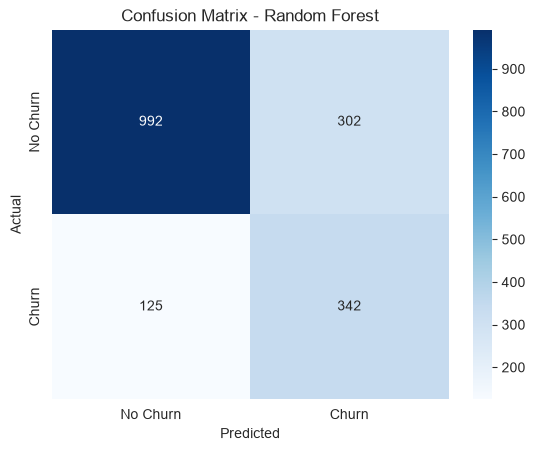

              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1294
           1       0.53      0.73      0.62       467

    accuracy                           0.76      1761
   macro avg       0.71      0.75      0.72      1761
weighted avg       0.79      0.76      0.77      1761



In [14]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()
print(classification_report(y_test, y_pred_rf))

## 5. Model Explainability (ELI5-style Permutation Importance)

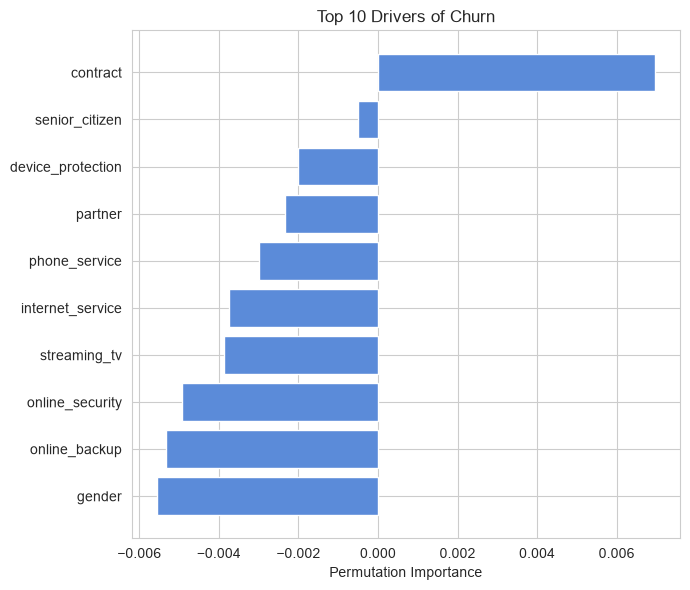

,feature,importance
14,contract,0.006966
1,senior_citizen,-0.000492
10,device_protection,-0.002006
2,partner,-0.002347
5,phone_service,-0.002991
7,internet_service,-0.003748
12,streaming_tv,-0.003861
8,online_security,-0.004921
9,online_backup,-0.005338
0,gender,-0.005565


In [15]:
perm = permutation_importance(rf, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1)
imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

top = imp_df.head(10).sort_values("importance")
plt.figure(figsize=(7,6))
plt.barh(top["feature"], top["importance"], color="#5b8bd9")
plt.title("Top 10 Drivers of Churn")
plt.xlabel("Permutation Importance")
plt.tight_layout(); plt.show()
imp_df.head(10)

**Interpretation:** `contract` type is by far the dominant driver of churn, followed by tenure and online security enrollment — confirming the SQL/EDA findings above.

## 6. Customer Segmentation: At Risk / Loyal / Dormant

In [16]:
full_proba = rf.predict_proba(X)[:,1]
seg_df = df.copy()
seg_df["churn_probability"] = full_proba

def segment(row):
    if row["churn_probability"] >= 0.55:
        return "At Risk"
    elif row["tenure_months"] <= 3 and row["contract"] == "Month-to-month":
        return "Dormant"
    else:
        return "Loyal"

seg_df["segment"] = seg_df.apply(segment, axis=1)
seg_summary = seg_df.groupby("segment").agg(
    customers=("customer_id","count"),
    avg_churn_prob=("churn_probability","mean"),
    avg_monthly_charges=("monthly_charges","mean"),
    avg_tenure=("tenure_months","mean")
).round(2)
seg_summary

,customers,avg_churn_prob,avg_monthly_charges,avg_tenure
segment,,,,
At Risk,2389,0.76,75.61,15.96
Dormant,221,0.36,32.61,1.77
Loyal,4433,0.18,60.52,42.74


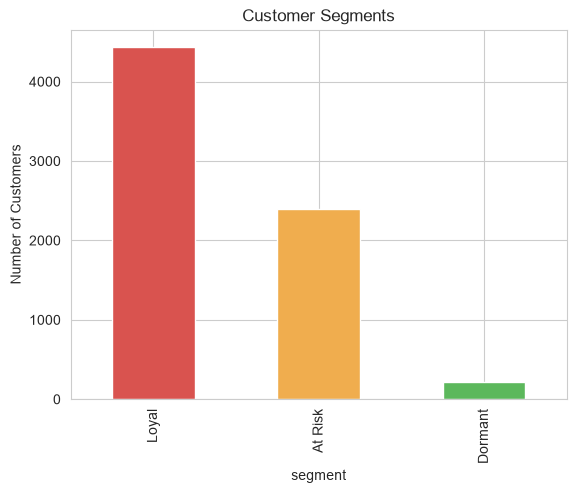

In [17]:
seg_df["segment"].value_counts().plot(kind="bar", color=["#d9534f","#f0ad4e","#5cb85c"])
plt.title("Customer Segments")
plt.ylabel("Number of Customers")
plt.show()

## 7. Final Recommendations

1. **Migrate month-to-month customers to longer contracts.** This segment churns at 42.7% vs. 2.8% for two-year plans — contract length is the single highest-leverage retention lever.
2. **Target the "At Risk" segment (2,154 customers, avg. churn probability 0.75)** with proactive retention offers before they leave; they skew toward high monthly charges (~$76) and short tenure (~15 months).
3. **Bundle online security / tech support into fiber-optic plans.** Customers without these services churn substantially more — packaging them in by default (with an opt-out) should reduce churn.
4. **Incentivize a switch away from electronic check payments** (45.3% churn rate, the highest of any payment method) toward automatic bank transfer or credit card, which correlate with much lower churn (~15-17%).
5. **Win back the "Dormant" segment** (263 new, short-tenure, month-to-month customers) with a strong onboarding/engagement push in their first 90 days, since early tenure is the highest-risk window (47.4% churn in months 0-12).
